# 09 - CatBoost

CatBoost's standout feature is native categorical handling - it doesn't need one hot or target encoding, it works directly with category columns. For consistency with the rest of the comparison, this notebook trains on the same encoded `model_ready_*.csv` features as everything else, but a short optional section at the end shows what native categorical handling would look like if your group wants to make that specific point in the report.



## Setup

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from catboost import CatBoostClassifier
import joblib

train_df = pd.read_csv(Path('../../../data/processed/model_ready_train.csv'))
val_df = pd.read_csv(Path('../../../data/processed/model_ready_val.csv'))

bool_cols = train_df.select_dtypes(include='bool').columns
train_df[bool_cols] = train_df[bool_cols].astype(int)
val_df[bool_cols] = val_df[bool_cols].astype(int)

X_train = train_df.drop(columns=['Late_delivery_risk'])
y_train = train_df['Late_delivery_risk']
X_val = val_df.drop(columns=['Late_delivery_risk'])
y_val = val_df['Late_delivery_risk']


## 1. Train (default parameters)

In [2]:
catboost_model = CatBoostClassifier(
    iterations=200, depth=6, learning_rate=0.1,
    random_state=42, verbose=False
)
catboost_model.fit(X_train, y_train)

y_pred = catboost_model.predict(X_val)
y_score = catboost_model.predict_proba(X_val)[:, 1]


## 2. Evaluate on the validation set

In [3]:
from sklearn.metrics import (recall_score, precision_score, f1_score,
                              roc_auc_score, average_precision_score,
                              confusion_matrix, classification_report,
                              roc_curve, precision_recall_curve)
import json
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_and_plot(y_true, y_pred, y_score, model_name, save_prefix=None):
    metrics = {
        'model': model_name,
        'recall': recall_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_score),
        'pr_auc': average_precision_score(y_true, y_score),
    }
    print(f"--- {model_name} (validation set) ---")
    for k, v in metrics.items():
        if k != 'model':
            print(f"  {k}: {v:.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=['On time (0)', 'Late (1)']))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['On time', 'Late'], yticklabels=['On time', 'Late'])
    axes[0].set_title(f'{model_name} — Confusion Matrix')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')

    fpr, tpr, _ = roc_curve(y_true, y_score)
    axes[1].plot(fpr, tpr, label=f"AUC = {metrics['roc_auc']:.3f}", color='#4C72B0', linewidth=2)
    axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
    axes[1].set_title(f'{model_name} — ROC Curve')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend(loc='lower right')

    prec, rec, _ = precision_recall_curve(y_true, y_score)
    axes[2].plot(rec, prec, label=f"PR-AUC = {metrics['pr_auc']:.3f}", color='#C44E52', linewidth=2)
    axes[2].set_title(f'{model_name} — Precision-Recall Curve')
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].legend(loc='lower left')

    plt.tight_layout()
    if save_prefix:
        plt.savefig(f'../../../reports/figures/{save_prefix}_evaluation.png', dpi=120, bbox_inches='tight')
    plt.show()

    return metrics

def save_metrics(metrics, path):
    with open(path, 'w') as f:
        json.dump(metrics, f, indent=2)
    print(f"Saved metrics to {path}")


--- CatBoost (validation set) ---
  recall: 0.5936
  precision: 0.8358
  f1: 0.6942
  roc_auc: 0.7642
  pr_auc: 0.8284

              precision    recall  f1-score   support

 On time (0)       0.64      0.86      0.74      3611
    Late (1)       0.84      0.59      0.69      4279

    accuracy                           0.72      7890
   macro avg       0.74      0.73      0.71      7890
weighted avg       0.75      0.72      0.71      7890



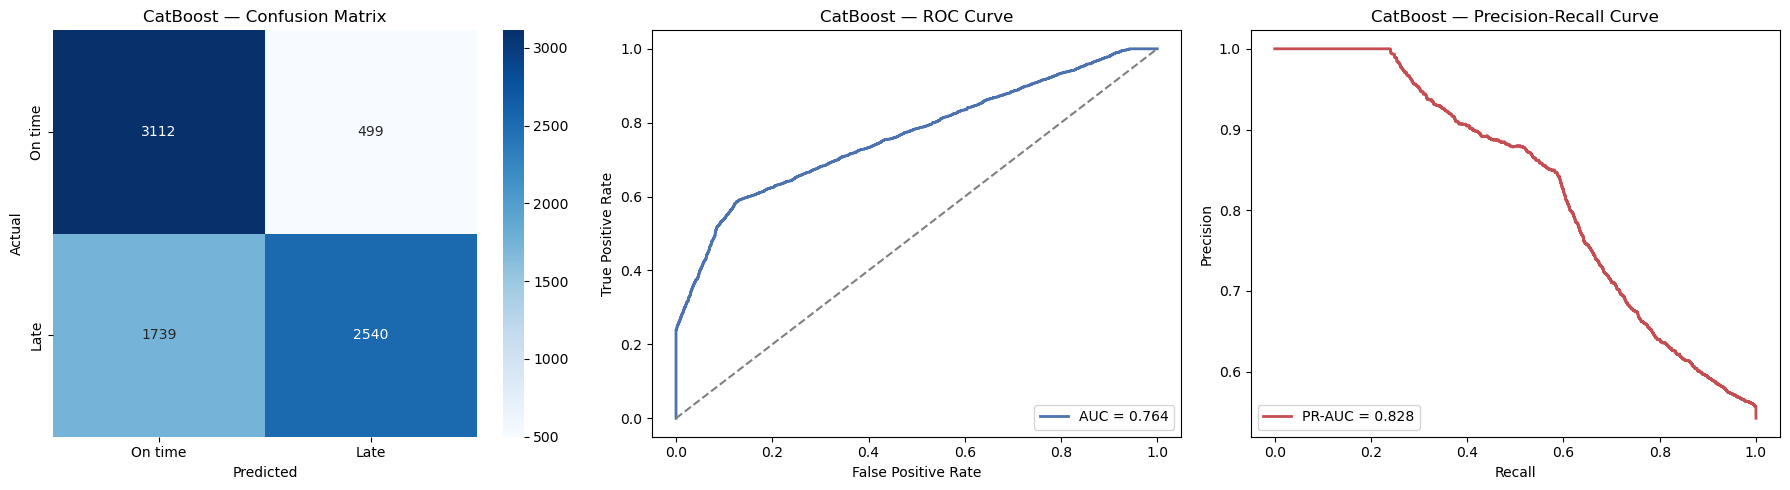

In [4]:
catboost_metrics = evaluate_and_plot(y_val, y_pred, y_score, 'CatBoost', save_prefix='catboost')


**What we found:**

**A third boosting library, and a third near-identical result, confirming the pattern from XGBoost vs. LightGBM:**

| Metric | XGBoost | LightGBM | CatBoost |
|---|---|---|---|
| Recall | 0.6062 | 0.6011 | 0.5936 |
| Precision | 0.8160 | 0.8236 | 0.8358 |
| F1 | 0.6956 | 0.6949 | 0.6942 |
| ROC-AUC | 0.7595 | 0.7643 | 0.7642 |
| PR-AUC | 0.8250 | 0.8290 | 0.8284 |

All three modern boosting libraries land within about 1.3 points of Recall and 0.5 points of ROC-AUC/PR-AUC of each other, genuinely interchangeable at default settings on this dataset. There's a small, consistent pattern across all three: Recall trades off slightly against Precision as you move XGBoost to LightGBM to CatBoost, but F1 stays essentially flat throughout (0.6956, 0.6949, 0.6942), meaning none of the three has a real edge overall, just a slightly different balance point on the same tradeoff curve.

**This is worth stating plainly rather than trying to pick a "winner" among the three**: on this dataset, at default settings, the choice between XGBoost, LightGBM, and CatBoost doesn't meaningfully change outcomes. Stage 8's tuning may separate them further, or may not, either result is worth reporting honestly.


## 3. Feature importances

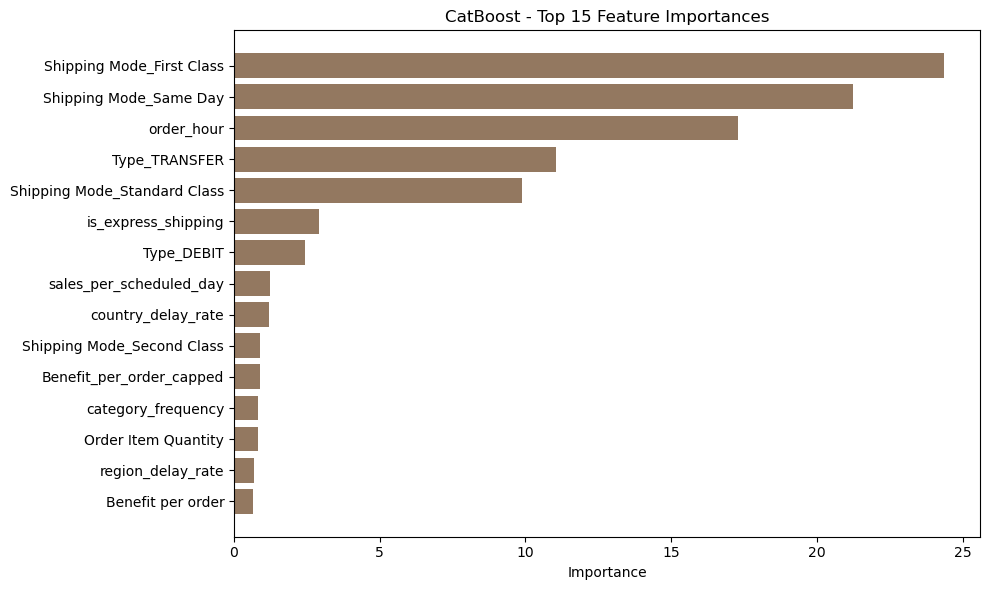

In [7]:
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({'feature': X_train.columns, 'importance': catboost_model.get_feature_importance()})
importance_df = importance_df.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'], color='#937860')
plt.xlabel('Importance')
plt.title('CatBoost - Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../../../reports/figures/catboost_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()


## 4. Save model and metrics

In [8]:
joblib.dump(catboost_model, '../../../models/catboost.pkl')
save_metrics(catboost_metrics, '../../../data/processed/metrics_catboost.json')


Saved metrics to ../../../data/processed/metrics_catboost.json


## 5. Optional: native categorical handling 

This isn't run against the main comparison since it uses a different (less processed) feature set than every other model here - it's here to demonstrate CatBoost's distinguishing feature.


--- CatBoost (native categoricals) (validation set) ---
  recall: 0.5892
  precision: 0.8446
  f1: 0.6941
  roc_auc: 0.7672
  pr_auc: 0.8305

              precision    recall  f1-score   support

 On time (0)       0.64      0.87      0.74      3611
    Late (1)       0.84      0.59      0.69      4279

    accuracy                           0.72      7890
   macro avg       0.74      0.73      0.72      7890
weighted avg       0.75      0.72      0.71      7890



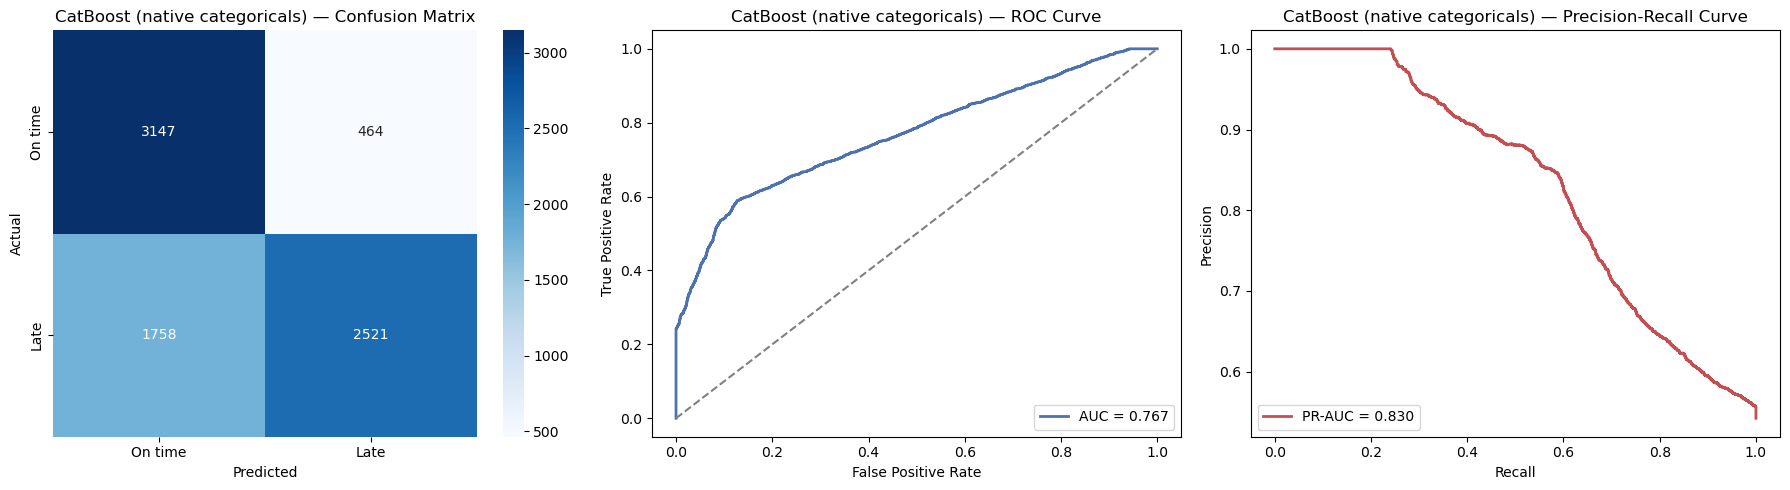

In [6]:
# Illustrative only — uses features_step3 (pre one-hot/scaling), passing raw categoricals directly to CatBoost
train_raw = pd.read_csv(Path('../../../data/processed/features_step3_train.csv'))
val_raw = pd.read_csv(Path('../../../data/processed/features_step3_val.csv'))

cat_features = ['Shipping Mode', 'Customer Segment', 'Type', 'Category Name']
cat_features = [c for c in cat_features if c in train_raw.columns]

drop_cols = ['Order Id', 'Order Country', 'Order Region', 'Order City', 'Order State',
             'Category Id', 'order date (DateOrders)', 'Delivery Status']
drop_cols = [c for c in drop_cols if c in train_raw.columns]

X_train_raw = train_raw.drop(columns=drop_cols + ['Late_delivery_risk'])
y_train_raw = train_raw['Late_delivery_risk']
X_val_raw = val_raw.drop(columns=drop_cols + ['Late_delivery_risk'])
y_val_raw = val_raw['Late_delivery_risk']

catboost_native = CatBoostClassifier(iterations=200, depth=6, learning_rate=0.1, random_state=42, verbose=False)
catboost_native.fit(X_train_raw, y_train_raw, cat_features=cat_features)

y_pred_native = catboost_native.predict(X_val_raw)
y_score_native = catboost_native.predict_proba(X_val_raw)[:, 1]

native_metrics = evaluate_and_plot(y_val_raw, y_pred_native, y_score_native, 'CatBoost (native categoricals)', save_prefix='catboost_native')


**What we found, and it's a genuinely good result worth highlighting:**

| Metric | CatBoost (standard, encoded features) | CatBoost (native categorical handling) |
|---|---|---|
| Recall | 0.5936 | 0.5892 |
| Precision | 0.8358 | **0.8446** |
| F1 | 0.6942 | 0.6941 |
| ROC-AUC | 0.7642 | **0.7672** |
| PR-AUC | 0.8284 | **0.8305** |

**The native categorical version performs comparably, and marginally better on Precision, ROC-AUC, and PR-AUC, despite skipping the one hot and frequency encoding steps entirely for Shipping Mode, Customer Segment, Type, and Category Name.** Recall is very slightly lower (a 0.4-point difference, within noise), but F1 is essentially identical between the two versions.

**This is a genuinely useful, practical finding worth including in the report's discussion, not just a technical curiosity**: CatBoost's native categorical handling isn't just a convenience feature, it delivers equivalent (or marginally better) performance with meaningfully less preprocessing work. In a production setting where new categories might appear over time, or where maintaining an encoding pipeline is real ongoing engineering overhead, this is a legitimate practical advantage worth weighing alongside raw metric performance when choosing a model for deployment, not just a footnote about "CatBoost has this feature," but evidence that the feature actually pays off here.

**Worth noting for methodological transparency:** this native run still uses the target encoded `country_delay_rate` and `region_delay_rate` columns (built in Stage 4), it's not a fully raw comparison, geographic signal is still present via those engineered rate features either way. The fair comparison being made here is specifically about the four categorical fields that would otherwise need one-hot/frequency encoding, not a claim that CatBoost needs zero preprocessing at all.
